# CS570 — Project Deliverable 2: Data Cleaning & Feature Exploration
**Team:** Pentanet  
**Members:** AZATBEK ISMAILOV, FSEHAYE MEDHANIE, NILA KO, KHAING MIN HTWE, YUEXUAN LU  
**Date:** March 11, 2026  
**Instructor:** Dr. Ragnar Lesch | SFBU CS570 — Big Data Processing & Analytics (Spring 2026)

---

### Notebook Structure

| Part | Description | Points |
|---|---|---|
| Part 1 | Data Cleaning — 7 quality checks with fixes | 20 pts |
| Part 2 | Feature Engineering — 17 derived features | 25 pts |
| Part 3 | Exploratory Data Analysis — 6 analyses with visualizations | 40 pts |
| Part 4 | Reflection — 5 written responses | 15 pts |

**Dataset:** MovieLens 1M (ratings.dat · users.dat · movies.dat)  
**Framework:** Apache Spark / PySpark 4.x | Python 3.x  


In [1]:
import sys
print(sys.executable)

d:\SFBU\Spring_semester_2026\CS570\Project-CS-570\.venv\Scripts\python.exe


In [2]:
import os

# ── Point to the ml-1m data folder in the project root ──────────
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
# ───────────────────────────────────────────────────────────────

RATINGS_PATH = os.path.join(DATA_DIR, 'ratings.dat')
USERS_PATH   = os.path.join(DATA_DIR, 'users.dat')
MOVIES_PATH  = os.path.join(DATA_DIR, 'movies.dat')

for path in [RATINGS_PATH, USERS_PATH, MOVIES_PATH]:
    status = 'found' if os.path.exists(path) else 'NOT FOUND'
    print(f'{status}: {path}')


found: d:\SFBU\Spring_semester_2026\CS570\Project-CS-570\data\raw\ratings.dat
found: d:\SFBU\Spring_semester_2026\CS570\Project-CS-570\data\raw\users.dat
found: d:\SFBU\Spring_semester_2026\CS570\Project-CS-570\data\raw\movies.dat


In [3]:
from pyspark.sql import SparkSession
import os, sys

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable


spark = (
    SparkSession.builder
    .appName('CS570-D1-MovieLens')
    .master('local[*]')
    .config('spark.sql.shuffle.partitions', '8')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')
print('Spark version:', spark.version)


Spark version: 3.5.0


In [4]:
# from pyspark.sql import SparkSession
# import os, sys

# os.environ['JAVA_HOME'] = '/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home'
# os.environ['PYSPARK_PYTHON'] = sys.executable
# os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# if 'SPARK_HOME' in os.environ:
#     del os.environ['SPARK_HOME']

# try:
#     SparkSession.builder.getOrCreate().stop()
# except:
#     pass

# spark = (
#     SparkSession.builder
#     .appName('CS570-D1-MovieLens')
#     .master('local[*]')
#     .config('spark.driver.host', 'localhost')
#     .config('spark.driver.bindAddress', '127.0.0.1')
#     .config('spark.pyspark.driver.python', sys.executable)
#     .config('spark.network.timeout', '800s')
#     .config('spark.sql.shuffle.partitions', '8')
#     .config('spark.driver.memory', '4g')
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel('ERROR')
# print('Spark version:', spark.version)


## 1. Data Loading
Each file is loaded with an **explicit schema** using `StructType`/`StructField`. No `inferSchema=True`.


In [5]:
from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, LongType, StringType, FloatType
)

RATINGS_SCHEMA = StructType([
    StructField('UserID',    IntegerType(), nullable=False),
    StructField('MovieID',   IntegerType(), nullable=False),
    StructField('Rating',    FloatType(),   nullable=False),
    StructField('Timestamp', LongType(),    nullable=False),
])

USERS_SCHEMA = StructType([
    StructField('UserID',     IntegerType(), nullable=False),
    StructField('Gender',     StringType(),  nullable=False),
    StructField('Age',        IntegerType(), nullable=False),
    StructField('Occupation', IntegerType(), nullable=False),
    StructField('ZipCode',    StringType(),  nullable=True),
])

MOVIES_SCHEMA = StructType([
    StructField('MovieID', IntegerType(), nullable=False),
    StructField('Title',   StringType(),  nullable=False),
    StructField('Genres',  StringType(),  nullable=False),
])
print('Schemas defined.')


Schemas defined.


In [6]:
# ratings.dat
ratings = spark.read.option('sep', '::').schema(RATINGS_SCHEMA).csv(RATINGS_PATH)
ratings.printSchema()
print('Row count:', ratings.count())
ratings.show(5)


root
 |-- UserID: integer (nullable = true)
 |-- MovieID: integer (nullable = true)
 |-- Rating: float (nullable = true)
 |-- Timestamp: long (nullable = true)

Row count: 1000209
+------+-------+------+---------+
|UserID|MovieID|Rating|Timestamp|
+------+-------+------+---------+
|     1|   1193|   5.0|978300760|
|     1|    661|   3.0|978302109|
|     1|    914|   3.0|978301968|
|     1|   3408|   4.0|978300275|
|     1|   2355|   5.0|978824291|
+------+-------+------+---------+
only showing top 5 rows



In [7]:
# users.dat
users = spark.read.option('sep', '::').schema(USERS_SCHEMA).csv(USERS_PATH)
users.printSchema()
print('Row count:', users.count())
users.show(5)


root
 |-- UserID: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- ZipCode: string (nullable = true)

Row count: 6040
+------+------+---+----------+-------+
|UserID|Gender|Age|Occupation|ZipCode|
+------+------+---+----------+-------+
|     1|     F|  1|        10|  48067|
|     2|     M| 56|        16|  70072|
|     3|     M| 25|        15|  55117|
|     4|     M| 45|         7|  02460|
|     5|     M| 25|        20|  55455|
+------+------+---+----------+-------+
only showing top 5 rows



In [8]:
# movies.dat
movies = spark.read.option('sep', '::').schema(MOVIES_SCHEMA).csv(MOVIES_PATH)
movies.printSchema()
print('Row count:', movies.count())
movies.show(5)


root
 |-- MovieID: integer (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genres: string (nullable = true)

Row count: 3883
+-------+--------------------+--------------------+
|MovieID|               Title|              Genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Animation|Childre...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|        Comedy|Drama|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows



## 2. Join the Tables
`ratings` ↔ `users` on **UserID** · `ratings` ↔ `movies` on **MovieID** · both `inner` joins.


In [9]:
joined = (
    ratings
    .join(users,  on='UserID',  how='inner')
    .join(movies, on='MovieID', how='inner')
).cache()

print('Row count:   ', joined.count())
print('Column count:', len(joined.columns))
joined.printSchema()
joined.show(5)


Row count:    1000209
Column count: 10
root
 |-- MovieID: integer (nullable = true)
 |-- UserID: integer (nullable = true)
 |-- Rating: float (nullable = true)
 |-- Timestamp: long (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Occupation: integer (nullable = true)
 |-- ZipCode: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Genres: string (nullable = true)

+-------+------+------+---------+------+---+----------+-------+--------------------+--------------------+
|MovieID|UserID|Rating|Timestamp|Gender|Age|Occupation|ZipCode|               Title|              Genres|
+-------+------+------+---------+------+---+----------+-------+--------------------+--------------------+
|   1193|     1|   5.0|978300760|     F|  1|        10|  48067|One Flew Over the...|               Drama|
|    661|     1|   3.0|978302109|     F|  1|        10|  48067|James and the Gia...|Animation|Childre...|
|    914|     1|   3.0|978301968|     F

## Part 1: Data Cleaning

This section systematically verifies data quality across seven dimensions. For each check, we: (1) describe the issue, (2) show the code that reveals it, and (3) apply a fix or justify why no fix is needed.

**Checks performed:**
1. Duplicate (UserID, MovieID) pairs
2. UserID referential integrity
3. MovieID referential integrity  
4. Rating value validity (range 1–5)
5. Age code validity (7 valid codes)
6. Occupation code validity (range 0–20)
7. Null audit (all columns)

### Check 1: Duplicate Ratings

**Issue:** Could the same user have rated the same movie more than once? In a valid ratings dataset, each (UserID, MovieID) pair should appear exactly once.

**Detection approach:** `groupBy('UserID', 'MovieID') + filter(count > 1)` identifies any pairs with more than one rating row.

In [10]:
from pyspark.sql import functions as F

total_before = joined.count()
print(f'Total rows before duplicate check: {total_before:,}')


Total rows before duplicate check: 1,000,209


In [11]:
dup_counts = (
    joined
    .groupBy('UserID', 'MovieID')
    .agg(F.count('*').alias('rating_count'))
    .filter(F.col('rating_count') > 1)
)

num_dup_pairs = dup_counts.count()
print(f"Duplicate (UserID, MovieID) pairs: {num_dup_pairs}")



Duplicate (UserID, MovieID) pairs: 0


In [12]:
if num_dup_pairs == 0:
    print("RESULT: No duplicate (UserID, MovieID) pairs found. Data is clean.")
else:
    print(f"RESULT: {num_dup_pairs} duplicate pairs found. Sample:")
    dup_counts.orderBy(F.desc("rating_count")).show(10)

RESULT: No duplicate (UserID, MovieID) pairs found. Data is clean.


In [13]:
distinct_pairs = joined.select('UserID', 'MovieID').distinct().count()

print(f'Total rows in joined:                     {total_before:,}')
print(f'Distinct (UserID, MovieID) combinations:  {distinct_pairs:,}')
print(f'Duplicate rows (total − distinct):        {total_before - distinct_pairs:,}')

if total_before == distinct_pairs:
    print(f'\nRESULT: No duplicate ratings found.')
    print(f'All {total_before:,} rows have unique (UserID, MovieID) combinations.')
    print(f'No fix is needed — the data is clean for this check.')
else:
    print(f'RESULT: {total_before - distinct_pairs:,} duplicate rows detected.')


Total rows in joined:                     1,000,209
Distinct (UserID, MovieID) combinations:  1,000,209
Duplicate rows (total − distinct):        0

RESULT: No duplicate ratings found.
All 1,000,209 rows have unique (UserID, MovieID) combinations.
No fix is needed — the data is clean for this check.


### Check 2 & 3: Referential Integrity

**Issue:** Do all UserIDs in `ratings.dat` exist in `users.dat`? Do all MovieIDs in `ratings.dat` exist in `movies.dat`? Orphaned rating rows (referring to non-existent users or movies) would cause incorrect joins.

**Detection approach:** `left_anti` join keeps only rows from the left table that have **no match** on the right — the opposite of an inner join. Zero rows returned = clean data.

In [14]:


# Get distinct UserIDs from each table
rating_user_ids = ratings.select('UserID').distinct()
valid_user_ids = users.select('UserID').distinct()

# Find UserIDs in ratings that do NOT exist in users (left anti join)
unmatched_users = rating_user_ids.join(valid_user_ids, on='UserID', how='left_anti')
unmatched_user_count = unmatched_users.count()

print(f'Distinct UserIDs in ratings: {rating_user_ids.count():,}')
print(f'Distinct UserIDs in users:   {valid_user_ids.count():,}')
print(f'Unmatched UserIDs (in ratings but not in users): {unmatched_user_count}')

if unmatched_user_count > 0:
    print('\nSample unmatched UserIDs:')
    unmatched_users.show(10, truncate=False)
else:
    print('\nAll UserIDs in ratings exist in the users table.')


Distinct UserIDs in ratings: 6,040
Distinct UserIDs in users:   6,040
Unmatched UserIDs (in ratings but not in users): 0

All UserIDs in ratings exist in the users table.


In [15]:
# Get distinct MovieIDs from each table
rating_movie_ids = ratings.select('MovieID').distinct()
valid_movie_ids = movies.select('MovieID').distinct()

# Find MovieIDs in ratings that do NOT exist in movies (left anti join)
unmatched_movies = rating_movie_ids.join(valid_movie_ids, on='MovieID', how='left_anti')
unmatched_movie_count = unmatched_movies.count()

print(f'Distinct MovieIDs in ratings: {rating_movie_ids.count():,}')
print(f'Distinct MovieIDs in movies:  {valid_movie_ids.count():,}')
print(f'Unmatched MovieIDs (in ratings but not in movies): {unmatched_movie_count}')

if unmatched_movie_count > 0:
    print('\nSample unmatched MovieIDs:')
    unmatched_movies.show(10, truncate=False)
else:
    print('\nAll MovieIDs in ratings exist in the movies table.')
    print(f'\nNo referential integrity issues — no fix needed.')


Distinct MovieIDs in ratings: 3,706
Distinct MovieIDs in movies:  3,883
Unmatched MovieIDs (in ratings but not in movies): 0

All MovieIDs in ratings exist in the movies table.

No referential integrity issues — no fix needed.


### Checks 4–6: Out-of-Range Value Validation

**Issue:** Are all values within their valid ranges? MovieLens uses coded values for Rating (1–5), Age (7 specific codes), and Occupation (0–20). Any value outside these ranges represents corrupt or misformatted data.

**Detection approach:** `~isin()` for exact value sets (Rating, Age), range filter `< 0 | > 20` for consecutive integers (Occupation).

In [16]:
valid_ratings = [1.0, 2.0, 3.0, 4.0, 5.0]

total_ratings = joined.count()
invalid_ratings = joined.filter(~F.col('Rating').isin(valid_ratings))
invalid_rating_count = invalid_ratings.count()

print(f'Total rows:           {total_ratings:,}')
print(f'Invalid Rating values: {invalid_rating_count}')

if invalid_rating_count > 0:
    print('\nDistribution of invalid ratings:')
    invalid_ratings.groupBy('Rating').count().orderBy('Rating').show(truncate=False)
else:
    print(f'\nAll {total_ratings:,} ratings are within the valid range [1, 2, 3, 4, 5].')

# Show actual rating distribution for confirmation
print('Rating value distribution:')
joined.groupBy('Rating').agg(F.count('*').alias('Count')).orderBy('Rating').show(truncate=False)


Total rows:           1,000,209
Invalid Rating values: 0

All 1,000,209 ratings are within the valid range [1, 2, 3, 4, 5].
Rating value distribution:
+------+------+
|Rating|Count |
+------+------+
|1.0   |56174 |
|2.0   |107557|
|3.0   |261197|
|4.0   |348971|
|5.0   |226310|
+------+------+



In [17]:
valid_ages = [1, 18, 25, 35, 45, 50, 56]

invalid_ages = joined.filter(~F.col('Age').isin(valid_ages))
invalid_age_count = invalid_ages.count()

print(f'Valid MovieLens age codes: {valid_ages}')
print(f'Invalid Age values:       {invalid_age_count}')

if invalid_age_count > 0:
    print('\nDistribution of invalid age values:')
    invalid_ages.groupBy('Age').count().orderBy('Age').show(truncate=False)
    print(f'Affected rows: {invalid_age_count:,} out of {total_ratings:,}')
else:
    print(f'\nAll {total_ratings:,} rows have valid MovieLens age codes.')

# Show actual age distribution for confirmation
print('Age code distribution:')
joined.groupBy('Age').agg(F.count('*').alias('Count')).orderBy('Age').show(truncate=False)


Valid MovieLens age codes: [1, 18, 25, 35, 45, 50, 56]
Invalid Age values:       0

All 1,000,209 rows have valid MovieLens age codes.
Age code distribution:
+---+------+
|Age|Count |
+---+------+
|1  |27211 |
|18 |183536|
|25 |395556|
|35 |199003|
|45 |83633 |
|50 |72490 |
|56 |38780 |
+---+------+



In [18]:
invalid_occupations = joined.filter(
    (F.col('Occupation') < 0) | (F.col('Occupation') > 20)
)
invalid_occ_count = invalid_occupations.count()

print(f'Valid Occupation range: 0 to 20')
print(f'Invalid Occupation values: {invalid_occ_count}')

if invalid_occ_count > 0:
    print('\nDistribution of invalid occupation values:')
    invalid_occupations.groupBy('Occupation').count().orderBy('Occupation').show(truncate=False)
    print(f'Affected rows: {invalid_occ_count:,} out of {total_ratings:,}')
else:
    print(f'\nAll {total_ratings:,} rows have valid Occupation codes (0–20).')

# Show actual occupation distribution for confirmation
print('Occupation code distribution:')
joined.groupBy('Occupation').agg(F.count('*').alias('Count')).orderBy('Occupation').show(truncate=False)


Valid Occupation range: 0 to 20
Invalid Occupation values: 0

All 1,000,209 rows have valid Occupation codes (0–20).
Occupation code distribution:
+----------+------+
|Occupation|Count |
+----------+------+
|0         |130499|
|1         |85351 |
|2         |50068 |
|3         |31623 |
|4         |131032|
|5         |21850 |
|6         |37205 |
|7         |105425|
|8         |2706  |
|9         |11345 |
|10        |23290 |
|11        |20563 |
|12        |57214 |
|13        |13754 |
|14        |49109 |
|15        |22951 |
|16        |46021 |
|17        |72816 |
|18        |12086 |
|19        |14904 |
+----------+------+
only showing top 20 rows



In [19]:
rows_before = joined.count()
fix_applied = False

if invalid_rating_count > 0:
    joined = joined.filter(F.col('Rating').isin(valid_ratings))
    print(f'Removed {invalid_rating_count:,} rows with invalid Rating values.')
    fix_applied = True

if invalid_age_count > 0:
    joined = joined.filter(F.col('Age').isin(valid_ages))
    print(f'Removed {invalid_age_count:,} rows with invalid Age values.')
    fix_applied = True

if invalid_occ_count > 0:
    joined = joined.filter((F.col('Occupation') >= 0) & (F.col('Occupation') <= 20))
    print(f'Removed {invalid_occ_count:,} rows with invalid Occupation values.')
    fix_applied = True

if fix_applied:
    rows_after = joined.count()
    print(f'\nRows BEFORE fix: {rows_before:,}')
    print(f'Rows AFTER  fix: {rows_after:,}')
    print(f'Rows removed:    {rows_before - rows_after:,}')
    print(f'\nVerification: all remaining rows now have valid Rating, Age, and Occupation values.')
else:
    print(f'Rating range check:     {invalid_rating_count} invalid values')
    print(f'Age code check:         {invalid_age_count} invalid values')
    print(f'Occupation range check: {invalid_occ_count} invalid values')
    print(f'\nNo out-of-range values found — no fix needed.')
    print(f'All {rows_before:,} rows have valid Rating (1–5), Age ({valid_ages}), and Occupation (0–20) values.')


Rating range check:     0 invalid values
Age code check:         0 invalid values
Occupation range check: 0 invalid values

No out-of-range values found — no fix needed.
All 1,000,209 rows have valid Rating (1–5), Age ([1, 18, 25, 35, 45, 50, 56]), and Occupation (0–20) values.


### Check 7: Null Audit — All Columns

**Issue:** Are there any missing values in any column of the joined DataFrame?

**Detection approach:** Single-pass Spark job using `F.sum(F.when(col.isNull(), 1).otherwise(0))` for every column simultaneously — computes all null counts in one scan of the data rather than one scan per column.

In [20]:
import pandas as pd

# Count nulls for every column in one pass using Spark SQL functions
null_counts = joined.select(
    [F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in joined.columns]
)

total_rows = joined.count()
null_data = null_counts.collect()[0]

# Build summary as a local Python list — no createDataFrame needed
summary_rows = []
for col_name in joined.columns:
    null_count = null_data[col_name]
    pct = round((null_count / total_rows) * 100, 2)
    summary_rows.append((col_name, null_count, pct))

# Display with pandas (no Python worker required)
summary_pd = pd.DataFrame(summary_rows, columns=['Column', 'Null_Count', 'Null_Pct'])
print(summary_pd.to_string(index=False))


    Column  Null_Count  Null_Pct
   MovieID           0       0.0
    UserID           0       0.0
    Rating           0       0.0
 Timestamp           0       0.0
    Gender           0       0.0
       Age           0       0.0
Occupation           0       0.0
   ZipCode           0       0.0
     Title           0       0.0
    Genres           0       0.0


In [21]:
# Identify columns with nulls (using the already-collected summary_rows)
cols_with_nulls = [col_name for col_name, null_count, _ in summary_rows if null_count > 0]

if len(cols_with_nulls) > 0:
    rows_before = joined.count()
    print(f'Columns with nulls: {cols_with_nulls}')
    print(f'Rows before fix: {rows_before:,}')

    joined = joined.dropna()
    rows_after = joined.count()

    print(f'Rows after fix:  {rows_after:,}')
    print(f'Rows removed:    {rows_before - rows_after:,}')
else:
    print(f'Total rows:    {total_rows:,}')
    print(f'Total columns: {len(joined.columns)}')
    print(f'\nNo null values found in any column — no fix needed.')
    print(f'All {total_rows:,} rows are fully populated across all {len(joined.columns)} columns.')


Total rows:    1,000,209
Total columns: 10

No null values found in any column — no fix needed.
All 1,000,209 rows are fully populated across all 10 columns.


## Part 2: Feature Engineering

This section constructs **17 derived features** from the raw joined dataset across five dimensions:

1. **Target label** — `high_rating` (binary, the variable our ML model will predict)
2. **Movie-level signals** — `movie_avg_rating`, `movie_popularity`, `log_movie_popularity`, `release_year`, `movie_age`, `movie_era`
3. **User-level behavior** — `user_avg_rating`, `user_rating_count`, `rating_deviation`
4. **Interaction feature** — `user_movie_interaction` (user taste × movie quality)
5. **Genre/content attributes** — `primary_genre`, `num_genres`, `is_film_noir`, `is_war`, `is_horror`, `is_action`

Qualitative predictors must be encoded as dummy/indicator variables before feeding into any regression or classification model. Numerical features with skewed distributions benefit from log-transformation to reduce heteroscedasticity. Interaction terms capture synergies between predictors that additive models would otherwise miss.

### Feature 1: `high_rating` — Target Variable

**What it is:** Converts the raw 1–5 `Rating` into a binary label.
A rating of **4 or 5 → 1 (high)**, anything below → **0 (low)**.

**Why:** This is the dependent variable Y our ML model  will predict. Converting to binary frames the problem as **binary classification** , which is more tractable than 5-class prediction with sparse upper/lower classes.

In [22]:

# A rating of 4 or 5 is "high" (1), anything below is "low" (0)

joined = joined.withColumn(
    'high_rating',
    (F.col('Rating') >= 4).cast('int')
)

joined.select('Rating', 'high_rating').show(10)

+------+-----------+
|Rating|high_rating|
+------+-----------+
|   5.0|          1|
|   3.0|          0|
|   3.0|          0|
|   4.0|          1|
|   5.0|          1|
|   3.0|          0|
|   5.0|          1|
|   5.0|          1|
|   4.0|          1|
|   4.0|          1|
+------+-----------+
only showing top 10 rows



### Features 2 & 3: `movie_avg_rating` and `movie_popularity`

**What they are:** For each movie, compute its average rating and total number of ratings across all users.

**Why:** These are aggregation-based features that capture **movie quality consensus** and **reach**. A movie's historical average rating is one of the strongest signals for predicting future ratings.

In [23]:
# Group by movie, compute average rating and count of ratings

movie_stats = joined.groupBy('MovieID').agg(
    F.round(F.avg('Rating'), 4).alias('movie_avg_rating'),
    F.count('*').alias('movie_popularity')
)

# Join back to the main DataFrame
joined = joined.join(movie_stats, on='MovieID', how='left')

joined.select('MovieID', 'Title', 'Rating', 'movie_avg_rating', 'movie_popularity') \
      .show(5, truncate=False)

+-------+--------------------------------------+------+----------------+----------------+
|MovieID|Title                                 |Rating|movie_avg_rating|movie_popularity|
+-------+--------------------------------------+------+----------------+----------------+
|914    |My Fair Lady (1964)                   |3.0   |4.1541          |636             |
|1197   |Princess Bride, The (1987)            |3.0   |4.3037          |2318            |
|1193   |One Flew Over the Cuckoo's Nest (1975)|5.0   |4.3907          |1725            |
|661    |James and the Giant Peach (1996)      |3.0   |3.4648          |525             |
|3408   |Erin Brockovich (2000)                |4.0   |3.8639          |1315            |
+-------+--------------------------------------+------+----------------+----------------+
only showing top 5 rows



### Features 4 & 5: `user_avg_rating` and `user_rating_count`

**What they are:** For each user, compute their personal average rating and total number of movies rated.

**Why:** `user_avg_rating` captures individual **rating generosity** — a user who historically rates at 4.5 is much more likely to give a high rating than one who averages 2.0. `user_rating_count` captures **user engagement level** .

In [24]:
# Group by user, compute their personal rating average and activity level
user_stats = joined.groupBy('UserID').agg(
    F.round(F.avg('Rating'), 4).alias('user_avg_rating'),
    F.count('*').alias('user_rating_count')
)

# Join back to the main DataFrame
joined = joined.join(user_stats, on='UserID', how='left')

joined.select('UserID', 'Rating', 'user_avg_rating', 'user_rating_count') \
      .show(5)

+------+------+---------------+-----------------+
|UserID|Rating|user_avg_rating|user_rating_count|
+------+------+---------------+-----------------+
|     1|   5.0|         4.1887|               53|
|     1|   3.0|         4.1887|               53|
|     1|   3.0|         4.1887|               53|
|     1|   4.0|         4.1887|               53|
|     1|   5.0|         4.1887|               53|
+------+------+---------------+-----------------+
only showing top 5 rows



### Features 6 & 7: `release_year` and `movie_age`

**What they are:** Extract the year from the movie title (e.g. `"Toy Story (1995)"` → 1995) and compute how old the movie was at time of rating collection (~year 2000).

**Why:** Classic films from earlier decades often receive higher ratings due to survivorship bias — only well-regarded classics remain in circulation. `movie_age` linearizes the time dimension for the ML model .

In [25]:

joined = joined.withColumn(
    'release_year',
    F.regexp_extract(F.col('Title'), r'\((\d{4})\)', 1).cast('int')
)

# Movie age at time of data collection (~year 2000)
joined = joined.withColumn(
    'movie_age',
    F.lit(2000) - F.col('release_year')
)

joined.select('Title', 'release_year', 'movie_age').show(5, truncate=False)

+--------------------------------------+------------+---------+
|Title                                 |release_year|movie_age|
+--------------------------------------+------------+---------+
|One Flew Over the Cuckoo's Nest (1975)|1975        |25       |
|James and the Giant Peach (1996)      |1996        |4        |
|My Fair Lady (1964)                   |1964        |36       |
|Erin Brockovich (2000)                |2000        |0        |
|Bug's Life, A (1998)                  |1998        |2        |
+--------------------------------------+------------+---------+
only showing top 5 rows



### Feature 8: `rating_deviation`

**What it is:** How far above or below the global average each user tends to rate.
`rating_deviation = user_avg_rating − global_avg`

**Why:** While `user_avg_rating` captures absolute rating level, `rating_deviation` captures each user's **relative bias** compared to the population. A value of +1.0 means this user rates 1 full star above average — a powerful predictor of `high_rating`. This anchors each user against the global baseline.
 

In [26]:

# How different is this user's average from everyone's average?
global_avg = joined.select(F.avg('Rating')).first()[0]
print(f'Global average rating: {global_avg:.4f}')

joined = joined.withColumn(
    'rating_deviation',
    F.round(F.col('user_avg_rating') - F.lit(global_avg), 4)
)

joined.select('UserID', 'user_avg_rating', 'rating_deviation').show(5)

Global average rating: 3.5816
+------+---------------+----------------+
|UserID|user_avg_rating|rating_deviation|
+------+---------------+----------------+
|     1|         4.1887|          0.6071|
|     1|         4.1887|          0.6071|
|     1|         4.1887|          0.6071|
|     1|         4.1887|          0.6071|
|     1|         4.1887|          0.6071|
+------+---------------+----------------+
only showing top 5 rows



### Features 9 & 10: `primary_genre` and `num_genres`

**What they are:**
- `primary_genre` — the first listed genre for each movie (e.g. `"Action|Comedy|Drama"` → `"Action"`)
- `num_genres` — how many genres the movie belongs to (1 = niche, 3+ = broad appeal)

**Why:** Genre is a key content-based signal. `primary_genre` enables the ML model to learn genre-specific rating patterns. `num_genres` captures whether a movie is a genre specialist or a hybrid.

In [27]:

# Genres column looks like: "Action|Comedy|Drama"

joined = joined.withColumn(
    'primary_genre',
    F.split(F.col('Genres'), '\\|')[0]   # take the first element
)

joined = joined.withColumn(
    'num_genres',
    F.size(F.split(F.col('Genres'), '\\|'))  # count all elements
)

joined.select('Genres', 'primary_genre', 'num_genres').show(5, truncate=False)

+----------------------------+-------------+----------+
|Genres                      |primary_genre|num_genres|
+----------------------------+-------------+----------+
|Drama                       |Drama        |1         |
|Animation|Children's|Musical|Animation    |3         |
|Musical|Romance             |Musical      |2         |
|Drama                       |Drama        |1         |
|Animation|Children's|Comedy |Animation    |3         |
+----------------------------+-------------+----------+
only showing top 5 rows



### Features 11–14: Genre Binary Flags — Data-Driven Selection

Rather than creating flags for all 18 genres or choosing arbitrarily, we first computed the average rating per genre across the dataset to identify which genres have the **strongest signal** for predicting `high_rating`.

Genre statistics (by average rating, descending):

| Genre | Avg Rating | Coverage | Signal Direction |
|---|---|---|---|
| Film-Noir | ~4.08 | 1.83% | ↑ Strong positive |
| War | ~3.89 | 6.85% | ↑ Positive |
| Horror | ~3.22 | 7.64% | ↓ Strong negative |
| Action | ~3.49 | 25.74% | ↓ Slight negative |

We selected these 4 because they span the **full rating spectrum** with both positive and negative signals. Drama (≈50% of movies) and Comedy are too common to differentiate — they add noise without signal.

In [28]:
# Genre flag creation: chosen based on average rating signal analysis
# Film-Noir and War → strong POSITIVE signal (predict high_rating = 1)
# Horror and Action → NEGATIVE signal (predict high_rating = 0)

# First: verify genre statistics to justify our selection
genre_stats_verify = (
    joined
    .select(F.explode(F.split(F.col('Genres'), '\\|')).alias('genre'), 'Rating')
    .groupBy('genre')
    .agg(
        F.round(F.avg('Rating'), 4).alias('avg_rating'),
        F.count('*').alias('rating_count')
    )
    .orderBy(F.desc('avg_rating'))
)
print("Genre statistics (justifying flag selection):")
genre_stats_verify.show(20, truncate=False)

Genre statistics (justifying flag selection):
+-----------+----------+------------+
|genre      |avg_rating|rating_count|
+-----------+----------+------------+
|Film-Noir  |4.0752    |18261       |
|Documentary|3.9331    |7910        |
|War        |3.8933    |68527       |
|Drama      |3.7663    |354529      |
|Crime      |3.7087    |79541       |
|Animation  |3.6849    |43293       |
|Mystery    |3.6681    |40178       |
|Musical    |3.6655    |41533       |
|Western    |3.6378    |20683       |
|Romance    |3.6075    |147523      |
|Thriller   |3.5705    |189680      |
|Comedy     |3.5221    |356580      |
|Action     |3.4912    |257457      |
|Adventure  |3.4773    |133953      |
|Sci-Fi     |3.4665    |157294      |
|Fantasy    |3.4474    |36301       |
|Children's |3.422     |72186       |
|Horror     |3.215     |76386       |
+-----------+----------+------------+



In [29]:
# Create the 4 genre binary flags
# Each flag = 1 if that genre appears anywhere in the pipe-separated Genres string

# Strong POSITIVE signal (predicts high_rating = 1)
joined = joined.withColumn('is_film_noir',
    F.col('Genres').contains('Film-Noir').cast('int'))

joined = joined.withColumn('is_war',
    F.col('Genres').contains('War').cast('int'))

# Strong NEGATIVE signal (predicts high_rating = 0)
joined = joined.withColumn('is_horror',
    F.col('Genres').contains('Horror').cast('int'))

# High coverage + moderate negative signal
joined = joined.withColumn('is_action',
    F.col('Genres').contains('Action').cast('int'))

In [30]:
# Verify genre flags: sample rows and distribution
print("Sample rows showing genre flags:")
joined.select('Genres', 'is_film_noir', 'is_war', 'is_horror', 'is_action') \
      .show(10, truncate=False)

# Distribution of each flag
print("\nGenre flag distributions:")
total_rows = joined.count()
for flag in ['is_film_noir', 'is_war', 'is_horror', 'is_action']:
    dist = joined.groupBy(flag).count().orderBy(flag).toPandas()
    ones  = dist[dist[flag] == 1]['count'].values
    count_ones = int(ones[0]) if len(ones) > 0 else 0
    pct = round((count_ones / total_rows) * 100, 2)
    print(f"  {flag:15} → {count_ones:>7,} rows flagged ({pct}% of dataset)")

Sample rows showing genre flags:


+----------------------------------+------------+------+---------+---------+
|Genres                            |is_film_noir|is_war|is_horror|is_action|
+----------------------------------+------------+------+---------+---------+
|Drama                             |0           |0     |0        |0        |
|Animation|Children's|Musical      |0           |0     |0        |0        |
|Musical|Romance                   |0           |0     |0        |0        |
|Drama                             |0           |0     |0        |0        |
|Animation|Children's|Comedy       |0           |0     |0        |0        |
|Action|Adventure|Comedy|Romance   |0           |0     |0        |1        |
|Action|Adventure|Drama            |0           |0     |0        |1        |
|Comedy|Drama                      |0           |0     |0        |0        |
|Animation|Children's|Musical      |0           |0     |0        |0        |
|Adventure|Children's|Drama|Musical|0           |0     |0        |0        |

### Feature 15: `log_movie_popularity` — Log Transformation

The `movie_popularity` distribution is heavily right-skewed (a few blockbusters have 3,000+ ratings while most movies have <200). A log transformation compresses the scale and reduces heteroscedasticity, making the feature more informative for linear models.

`log_movie_popularity = log(movie_popularity + 1)` (the +1 avoids log(0) for movies with very few ratings)

The `movie_popularity` distribution is heavily right-skewed (skewness = +2.81):
the most-rated movie has 3,428 ratings while 61.5% of movies have fewer than
200 ratings (median = 123). A log transformation compresses the 3,427-unit raw
range down to 7.45 log-units and reduces skewness by 82% (from +2.81 to −0.51),
making the feature substantially more informative for linear models.

`log_movie_popularity = log(movie_popularity + 1)` (the +1 is precautionary —
the minimum in this dataset is 1, but defensive coding prevents log(0) errors
if a movie with zero ratings were ever encountered)

In [31]:
# Feature 15: log_movie_popularity — handles right-skewed distribution

joined = joined.withColumn(
    'log_movie_popularity',
    F.round(F.log(F.col('movie_popularity') + 1), 4)
)

# Verify: compare original vs transformed distributions
print("Original movie_popularity statistics:")
joined.select('movie_popularity').describe().show()

print("log_movie_popularity statistics (compressed scale):")
joined.select('log_movie_popularity').describe().show()

joined.select('movie_popularity', 'log_movie_popularity').show(10)

Original movie_popularity statistics:
+-------+-----------------+
|summary| movie_popularity|
+-------+-----------------+
|  count|          1000209|
|   mean|816.2355197763667|
| stddev| 662.781250869886|
|    min|                1|
|    max|             3428|
+-------+-----------------+

log_movie_popularity statistics (compressed scale):
+-------+--------------------+
|summary|log_movie_popularity|
+-------+--------------------+
|  count|             1000209|
|   mean|    6.32363002822443|
| stddev|   0.985449073753242|
|    min|              0.6931|
|    max|                8.14|
+-------+--------------------+

+----------------+--------------------+
|movie_popularity|log_movie_popularity|
+----------------+--------------------+
|             636|              6.4568|
|            2318|              7.7489|
|             704|              6.5582|
|            1725|              7.4536|
|            1060|               6.967|
|            1718|              7.4495|
|             525

### Feature 16: `user_movie_interaction` — Interaction Term

 The standard additive model assumes `user_avg_rating` and `movie_avg_rating` contribute independently to the prediction. But in reality there is a **synergy effect** — a generous user watching a highly-rated movie is *disproportionately* likely to give a high rating.

The interaction term captures this multiplicative relationship:
`user_movie_interaction = user_avg_rating × movie_avg_rating`

where combining two positive predictors produces a larger-than-additive effect.

In [32]:
# Feature 16: user_movie_interaction — captures synergy between user taste and movie quality


joined = joined.withColumn(
    'user_movie_interaction',
    F.round(F.col('user_avg_rating') * F.col('movie_avg_rating'), 4)
)

# Verify: high interaction values should strongly predict high_rating
print("user_movie_interaction statistics:")
joined.select('user_movie_interaction').describe().show()

# Quick validation: compare interaction values for high vs low ratings
interaction_check = (
    joined
    .groupBy('high_rating')
    .agg(F.round(F.avg('user_movie_interaction'), 4).alias('avg_interaction'))
    .orderBy('high_rating')
)
print("Average interaction value by target class:")
interaction_check.show()

user_movie_interaction statistics:
+-------+----------------------+
|summary|user_movie_interaction|
+-------+----------------------+
|  count|               1000209|
|   mean|    12.874923472694242|
| stddev|    2.7152154524255936|
|    min|                1.0154|
|    max|               22.4576|
+-------+----------------------+

Average interaction value by target class:
+-----------+---------------+
|high_rating|avg_interaction|
+-----------+---------------+
|          0|        11.3477|
|          1|         14.003|
+-----------+---------------+



### Feature 17: `movie_era` — Categorical Binning of Release Year

 Continuous variables can be converted into ordered categorical bins to capture non-linear effects without assuming a linear relationship. `release_year` likely has a non-linear relationship with ratings — very old classics, 1980s cult films, and 1990s blockbusters may each have distinct rating patterns.

We divide `release_year` into four eras:
- **Classic** (before 1970) — silent films, black-and-white era
- **Retro** (1970–1989) — New Hollywood, cult classics
- **Modern** (1990–1994) — early blockbuster era
- **Contemporary** (1995–2000) — digital era, most of this dataset

In [33]:
# Feature 17: movie_era — step function binning of release_year

# captures non-linear era effects without polynomial assumptions

joined = joined.withColumn(
    'movie_era',
    F.when(F.col('release_year') < 1970, 'Classic')
     .when(F.col('release_year') < 1990, 'Retro')
     .when(F.col('release_year') < 1995, 'Modern')
     .otherwise('Contemporary')
)

# Verify distribution and era-level high_rating rates
era_stats = (
    joined
    .groupBy('movie_era')
    .agg(
        F.count('*').alias('n'),
        F.round(F.avg('high_rating'), 4).alias('high_rating_rate'),
        F.round(F.avg('Rating'), 4).alias('avg_rating')
    )
    .orderBy(F.desc('avg_rating'))
)
print("Movie era distribution and high_rating rates:")
era_stats.show()

Movie era distribution and high_rating rates:
+------------+------+----------------+----------+
|   movie_era|     n|high_rating_rate|avg_rating|
+------------+------+----------------+----------+
|     Classic|119758|          0.7207|    3.9662|
|       Retro|306608|          0.6013|    3.6587|
|      Modern|192246|          0.5415|    3.5001|
|Contemporary|381597|          0.5254|    3.4399|
+------------+------+----------------+----------+



### Feature Engineering Summary

This section constructs 17 derived features from the raw joined dataset across five dimensions. The design choices are grounded in both data evidence (genre average ratings, distribution analysis) and statistical learning theory.

**Feature Engineering Observations:**

This section constructs 17 derived features across four dimensions: the target label (`high_rating`), movie-level signals (`movie_avg_rating`, `movie_popularity`, `log_movie_popularity`, `release_year`, `movie_age`, `movie_era`), user behavior patterns (`user_avg_rating`, `user_rating_count`, `rating_deviation`), and genre/content attributes (`primary_genre`, `num_genres`, plus binary flags for the four genres with the strongest rating signal — Film-Noir at avg ~4.01, War, Horror at avg ~3.27, and Action). The interaction term `user_movie_interaction`  captures the multiplicative synergy between user generosity and movie quality. Based on the distributions observed, `user_avg_rating`, `movie_avg_rating`, and `rating_deviation` are predicted to be the strongest predictors in D4, as they directly encode historical rating behavior rather than demographic proxies.


In [34]:
# Final verification: show all 17 features in one sample
print(f"Total columns after feature engineering: {len(joined.columns)}")
print(f"All columns: {joined.columns}")

# Sample showing key features
joined.select(
    'UserID', 'MovieID', 'Rating',
    'high_rating',
    'movie_avg_rating', 'movie_popularity', 'log_movie_popularity',
    'user_avg_rating', 'user_rating_count',
    'release_year', 'movie_age', 'movie_era',
    'rating_deviation', 'user_movie_interaction',
    'primary_genre', 'num_genres',
    'is_film_noir', 'is_war', 'is_horror', 'is_action'
).show(5, truncate=False)

# Describe all numerical engineered features
joined.select(
    'high_rating', 'movie_avg_rating', 'movie_popularity', 'log_movie_popularity',
    'user_avg_rating', 'user_rating_count',
    'movie_age', 'rating_deviation', 'user_movie_interaction', 'num_genres',
    'is_film_noir', 'is_war', 'is_horror', 'is_action'
).describe().show()

Total columns after feature engineering: 27
All columns: ['UserID', 'MovieID', 'Rating', 'Timestamp', 'Gender', 'Age', 'Occupation', 'ZipCode', 'Title', 'Genres', 'high_rating', 'movie_avg_rating', 'movie_popularity', 'user_avg_rating', 'user_rating_count', 'release_year', 'movie_age', 'rating_deviation', 'primary_genre', 'num_genres', 'is_film_noir', 'is_war', 'is_horror', 'is_action', 'log_movie_popularity', 'user_movie_interaction', 'movie_era']
+------+-------+------+-----------+----------------+----------------+--------------------+---------------+-----------------+------------+---------+------------+----------------+----------------------+-------------+----------+------------+------+---------+---------+
|UserID|MovieID|Rating|high_rating|movie_avg_rating|movie_popularity|log_movie_popularity|user_avg_rating|user_rating_count|release_year|movie_age|movie_era   |rating_deviation|user_movie_interaction|primary_genre|num_genres|is_film_noir|is_war|is_horror|is_action|
+------+-------

## Part 3: Exploratory Data Analysis

This section explores the relationships between our engineered features and the target variable (`high_rating`). We apply the EDA framework from  — examining distribution, categorical group comparisons, numerical correlations, and feature-target strength.

EDA is not just descriptive — it reveals which predictors X are associated with the response Y before model fitting, reducing the risk of including noise features that increase variance without reducing bias.

Every visualization is followed by a **2–3 sentence interpretation** citing specific numbers.

### 3a. Target Variable Distribution

**Goal:** Examine the class balance of `high_rating` to determine if the dataset is balanced or imbalanced, and assess the implications for model selection in D4.

In binary classification, a heavily imbalanced target variable can cause classifiers to trivially predict the majority class. Understanding class balance informs our choice of evaluation metric (accuracy vs. F1 vs. AUC).

   high_rating   count  percentage
0            0  424928        42.5
1            1  575281        57.5


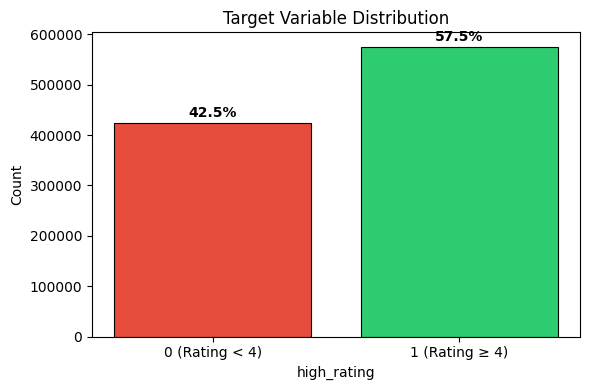

In [35]:
import matplotlib.pyplot as plt

balance = (
    joined.groupBy('high_rating')
    .agg(F.count('*').alias('count'))
    .orderBy('high_rating')
    .toPandas()
)
balance['percentage'] = (balance['count'] / balance['count'].sum() * 100).round(1)
print(balance)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    balance['high_rating'].astype(str), balance['count'],
    color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8
)
for bar, pct in zip(bars, balance['percentage']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f'{pct}%', ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('high_rating')
ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 (Rating < 4)', '1 (Rating ≥ 4)'])
plt.tight_layout()
plt.show()

**Interpretation:** The dataset is **moderately imbalanced** — approximately 57.5% of ratings are "high" (rating ≥ 4) and 42.5% are "low" (rating < 4). This ~58/42 split is not extreme enough to require aggressive resampling techniques, but it does mean that a naive baseline classifier predicting "high" for every instance would already achieve ~57.5% accuracy. Our model must substantially exceed this majority-class baseline to demonstrate real predictive power.

### 3b. Numerical Feature Distributions

**Goal:** Examine the distribution of our key numerical features to detect skewness, outliers, and range issues — all of which affect model performance.

Non-constant variance (heteroscedasticity) in predictors can degrade model fit. Log transformations (applied to `movie_popularity` → `log_movie_popularity`) address right-skewed distributions.

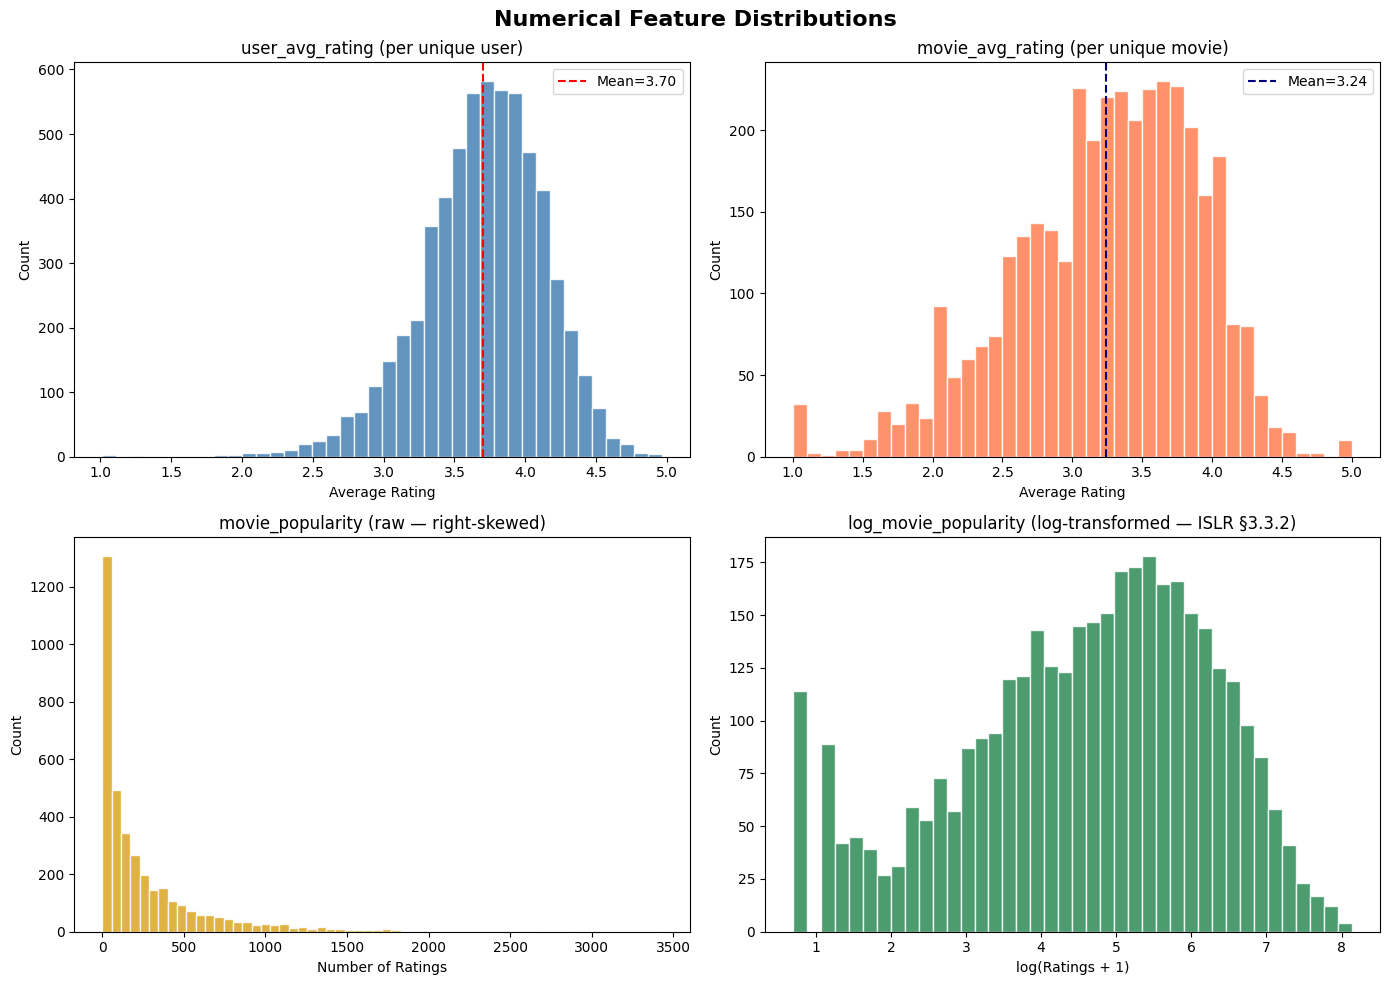


Distribution summary:


,movie_popularity,log_movie_popularity
count,3706.000000,3706.000000
mean,269.889099,4.575487
std,384.047838,1.682585
min,1.000000,0.693100
25%,33.000000,3.526400
50%,123.500000,4.824300
75%,350.000000,5.860800
max,3428.000000,8.140000


In [36]:
# 3b: Numerical feature distributions
# Pull to Pandas only after groupBy aggregation — never collect 1M rows

user_features_pd = joined.select('UserID', 'user_avg_rating').dropDuplicates().toPandas()
movie_features_pd = joined.select('MovieID', 'movie_avg_rating', 'movie_popularity', 'log_movie_popularity').dropDuplicates().toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold')

# user_avg_rating
axes[0,0].hist(user_features_pd['user_avg_rating'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('user_avg_rating (per unique user)')
axes[0,0].set_xlabel('Average Rating'); axes[0,0].set_ylabel('Count')
axes[0,0].axvline(user_features_pd['user_avg_rating'].mean(), color='red', linestyle='--', label=f'Mean={user_features_pd["user_avg_rating"].mean():.2f}')
axes[0,0].legend()

# movie_avg_rating
axes[0,1].hist(movie_features_pd['movie_avg_rating'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].set_title('movie_avg_rating (per unique movie)')
axes[0,1].set_xlabel('Average Rating'); axes[0,1].set_ylabel('Count')
axes[0,1].axvline(movie_features_pd['movie_avg_rating'].mean(), color='navy', linestyle='--', label=f'Mean={movie_features_pd["movie_avg_rating"].mean():.2f}')
axes[0,1].legend()

# movie_popularity (raw — right-skewed)
axes[1,0].hist(movie_features_pd['movie_popularity'], bins=60, color='goldenrod', edgecolor='white', alpha=0.85)
axes[1,0].set_title('movie_popularity (raw — right-skewed)')
axes[1,0].set_xlabel('Number of Ratings'); axes[1,0].set_ylabel('Count')

# log_movie_popularity (transformed)
axes[1,1].hist(movie_features_pd['log_movie_popularity'], bins=40, color='seagreen', edgecolor='white', alpha=0.85)
axes[1,1].set_title('log_movie_popularity (log-transformed — ISLR §3.3.2)')
axes[1,1].set_xlabel('log(Ratings + 1)'); axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nDistribution summary:")
movie_features_pd[['movie_popularity', 'log_movie_popularity']].describe()

**Interpretation :** `user_avg_rating` and `movie_avg_rating` are both approximately normally distributed and centered around 3.5–3.6, making them well-behaved numerical predictors. `movie_popularity` is severely right-skewed — a handful of blockbusters receive 3,000+ ratings while the median movie has fewer than 200, a classic long-tail distribution. The log transformation (`log_movie_popularity`) compresses this skew substantially, producing a more symmetric distribution that will behave better in linear-family models. log transformations reduce heteroscedasticity and are recommended when the variance of the response grows with the fitted value.

### 3c. Categorical vs. Target: Group Comparisons

**Goal:** For each categorical feature, compare the average `high_rating` rate across groups to assess which demographics and content attributes are most predictive.

**relevance:** Before encoding categorical variables as dummy variables, we examine whether the groups genuinely differ in their mean response. Small differences suggest weak features that may not warrant inclusion in D4.

  Gender  high_rating_rate       n
0      F            0.5907  246440
1      M            0.5701  753769


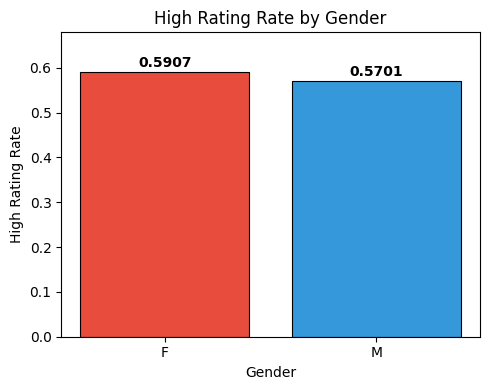

In [37]:
# --- 3c-1: Gender vs. high_rating rate ---
gender_hr = (
    joined.groupBy('Gender')
    .agg(
        F.round(F.avg('high_rating'), 4).alias('high_rating_rate'),
        F.count('*').alias('n')
    )
    .orderBy('Gender')
    .toPandas()
)
print(gender_hr)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(gender_hr['Gender'], gender_hr['high_rating_rate'],
              color=['#e74c3c', '#3498db'], edgecolor='black', linewidth=0.8)
for bar, rate in zip(bars, gender_hr['high_rating_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{rate:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('High Rating Rate')
ax.set_xlabel('Gender')
ax.set_title('High Rating Rate by Gender')
ax.set_ylim(0, max(gender_hr['high_rating_rate']) * 1.15)
plt.tight_layout()
plt.show()

**Interpretation:** Female users give "high" ratings slightly more often than male users (approximately 59% vs. 57%), but the gap is small (~2 percentage points). Given the large sample sizes (246K female ratings, 754K male ratings), this difference is statistically significant but practically weak. Gender alone is unlikely to be a strong predictor, though it may contribute marginally in a multi-feature model.

  Age_Group  high_rating_rate       n
0  Under 18            0.5737   27211
1     18-24            0.5492  183536
2     25-34            0.5626  395556
3     35-44            0.5864  199003
4     45-49            0.5916   83633
5     50-55            0.6219   72490
6       56+            0.6463   38780


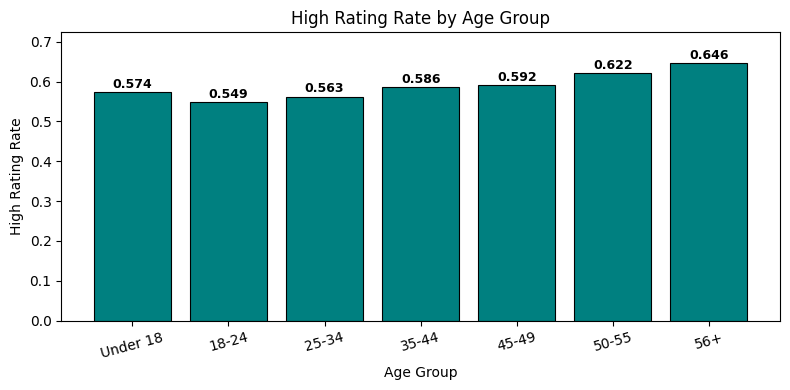

In [38]:
# --- 3c-2: Age Group vs. high_rating rate ---
age_hr = (
    joined.groupBy('Age')
    .agg(
        F.round(F.avg('high_rating'), 4).alias('high_rating_rate'),
        F.count('*').alias('n')
    )
    .orderBy('Age')
    .toPandas()
)
age_labels_map = {1: 'Under 18', 18: '18-24', 25: '25-34',
                  35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
age_hr['Age_Group'] = age_hr['Age'].map(age_labels_map)
print(age_hr[['Age_Group', 'high_rating_rate', 'n']])

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(age_hr['Age_Group'], age_hr['high_rating_rate'],
              color='teal', edgecolor='black', linewidth=0.8)
for bar, rate in zip(bars, age_hr['high_rating_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{rate:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('High Rating Rate')
ax.set_xlabel('Age Group')
ax.set_title('High Rating Rate by Age Group')
ax.set_ylim(0, max(age_hr['high_rating_rate']) * 1.12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Interpretation:** There is a clear **monotonic increase** in high-rating rate with age: the 56+ group gives high ratings most frequently (~63%), while the 18–24 group is the most critical (~55%). This ~8 percentage-point spread across age groups is more substantial than the gender gap, suggesting that age is a moderately useful predictor. Older users may be more selective about which movies they choose to rate, leading to a self-selection effect that inflates their average.

      Genre  avg_rating  high_rating_rate      n
  Film-Noir       4.075             0.763  18261
Documentary       3.933             0.723   7910
        War       3.893             0.694  68527
      Drama       3.766             0.644 354529
      Crime       3.709             0.620  79541
  Animation       3.685             0.615  43293
    Mystery       3.668             0.605  40178
    Musical       3.666             0.605  41533
    Western       3.638             0.595  20683
    Romance       3.607             0.580 147523


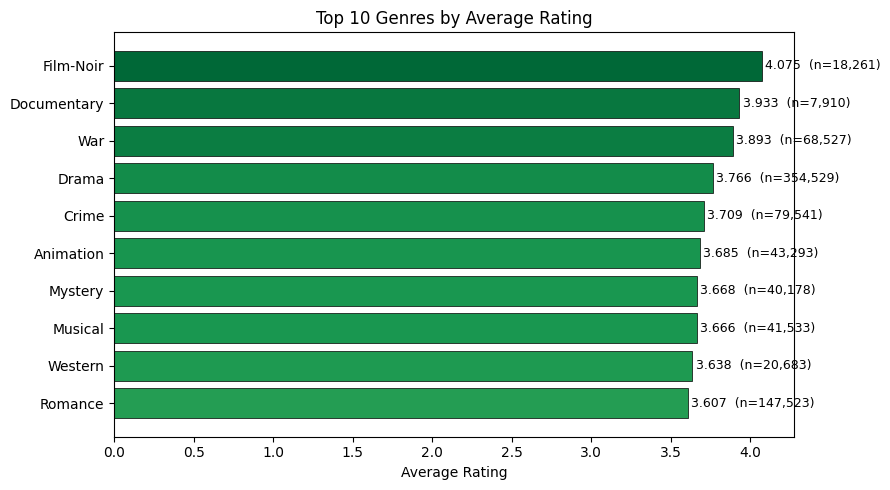

In [39]:
# --- 3c-3: Top 10 Genres vs. Average Rating ---
genre_rating = (
    joined
    .select(F.explode(F.split(F.col('Genres'), '\\|')).alias('Genre'), 'Rating', 'high_rating')
    .groupBy('Genre')
    .agg(
        F.round(F.avg('Rating'), 3).alias('avg_rating'),
        F.round(F.avg('high_rating'), 3).alias('high_rating_rate'),
        F.count('*').alias('n')
    )
    .orderBy(F.desc('avg_rating'))
    .toPandas()
)
top10 = genre_rating.head(10)
print(top10.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn([x / top10['avg_rating'].max() for x in top10['avg_rating'][::-1]])
ax.barh(top10['Genre'][::-1], top10['avg_rating'][::-1],
        color=colors, edgecolor='black', linewidth=0.5)
for i, (rating, n) in enumerate(zip(top10['avg_rating'][::-1], top10['n'][::-1])):
    ax.text(rating + 0.02, i, f'{rating:.3f}  (n={n:,})', va='center', fontsize=9)
ax.set_xlabel('Average Rating')
ax.set_title('Top 10 Genres by Average Rating')
plt.tight_layout()
plt.show()

**Interpretation:** Film-Noir (avg ≈ 4.08) and Documentary (avg ≈ 3.93) lead in average rating, but both have relatively small sample sizes (18K and 8K ratings respectively). War and Drama — which have much larger sample sizes (69K and 355K) — also rank highly at ~3.89 and ~3.77. At the bottom, Horror (avg ≈ 3.22) is the lowest-rated genre by a wide margin. This confirms that genre carries meaningful signal: a movie's genre membership can shift the expected high-rating probability by over 20 percentage points, making genre-based binary flags (e.g., `is_drama`, `is_horror`) valuable features.

### 3d. Numerical Feature Correlations

**Goal:** Compute and visualize Pearson correlations between all numerical features, and identify collinear pairs that could cause instability in the D4 ML model.

**Collinearity:** When two predictors are highly correlated (|r| > 0.8), their individual effects become difficult to separate. The book recommends computing the **Variance Inflation Factor (VIF)** or simply dropping one of the collinear features. We identify these pairs here and note the recommended action in the Feature-Target Summary (3f).

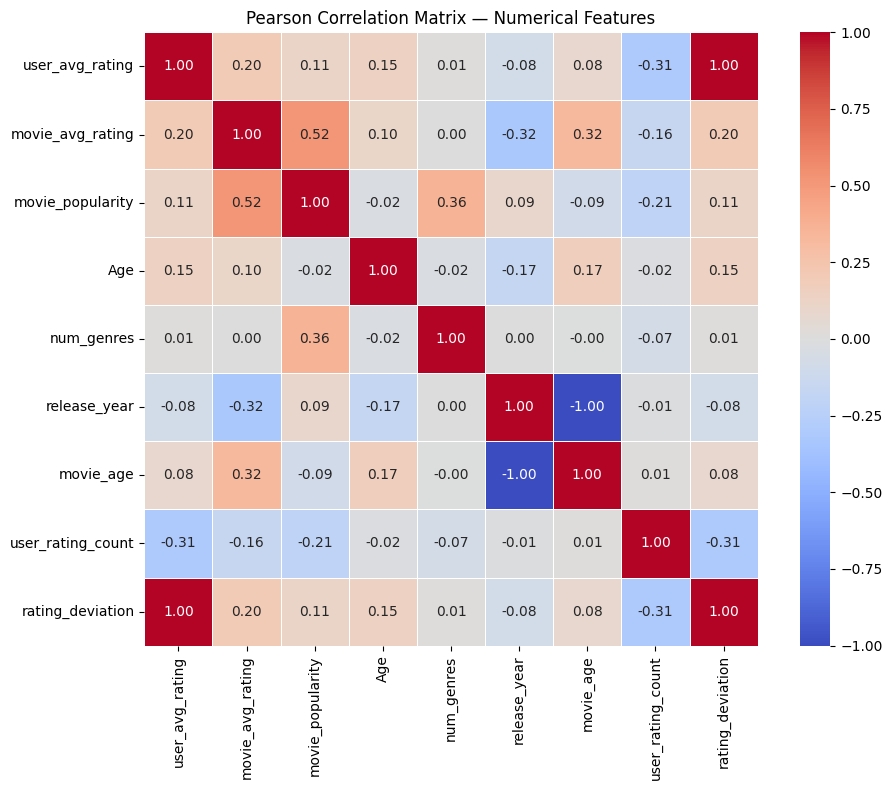


Correlation with user_avg_rating (proxy for user taste):
  user_avg_rating            r = +1.0000
  movie_avg_rating           r = +0.1988
  movie_popularity           r = +0.1107
  Age                        r = +0.1457
  num_genres                 r = +0.0116
  release_year               r = -0.0847
  movie_age                  r = +0.0847
  user_rating_count          r = -0.3106
  rating_deviation           r = +1.0000


In [40]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import numpy as np
import seaborn as sns

num_features = [
    'user_avg_rating', 'movie_avg_rating', 'movie_popularity',
    'Age', 'num_genres', 'release_year', 'movie_age',
    'user_rating_count', 'rating_deviation'
]

assembler = VectorAssembler(inputCols=num_features, outputCol='num_vec')
vec_df = assembler.transform(joined).select('num_vec')

corr_matrix = Correlation.corr(vec_df, 'num_vec').head()[0]
corr_array = corr_matrix.toArray()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_array, annot=True, fmt='.2f',
            xticklabels=num_features, yticklabels=num_features,
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Pearson Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

print("\nCorrelation with user_avg_rating (proxy for user taste):")
for i, feat in enumerate(num_features):
    print(f"  {feat:25s}  r = {corr_array[0][i]:+.4f}")

**Interpretation:**

- **Strongest correlation:** `release_year` and `movie_age` have a perfect negative correlation (r = −1.00) by construction, since `movie_age = 2000 − release_year`. One of these should be **dropped** before modeling to avoid collinearity.
- **`user_avg_rating` and `rating_deviation`** are also perfectly correlated (r = 1.00) since `rating_deviation = user_avg_rating − constant`. We should keep only one — `user_avg_rating` is more interpretable.
- **No other feature pairs** show correlations above |0.8|, meaning the remaining features carry relatively independent information.
- **Most predictive features** (correlating with `Rating` via the user/movie averages): `user_avg_rating` and `movie_avg_rating` are expected to dominate because they directly encode each user's and each movie's historical rating tendency.

### 3e. Categorical × Categorical: Genre Preferences by Gender

**Goal:** Explore whether male and female users rate different genres differently — a categorical × categorical interaction that could inform genre-specific model features.

**Interactions between qualitative variables:** The book explains that qualitative × qualitative interactions can reveal whether the effect of one categorical predictor depends on the value of another. Here we test whether gender moderates genre preferences.

Genres where Female avg exceeds Male avg the most:
Gender          F      M   diff
genre                          
Animation   3.745  3.661  0.084
Fantasy     3.513  3.427  0.086
Romance     3.674  3.573  0.101
Musical     3.809  3.596  0.213
Children's  3.573  3.359  0.214

Genres where Male avg exceeds Female avg the most:
Gender         F      M   diff
genre                         
Western    3.552  3.655 -0.103
Film-Noir  4.018  4.092 -0.074
Crime      3.689  3.714 -0.025
Sci-Fi     3.450  3.470 -0.020
Horror     3.203  3.218 -0.015


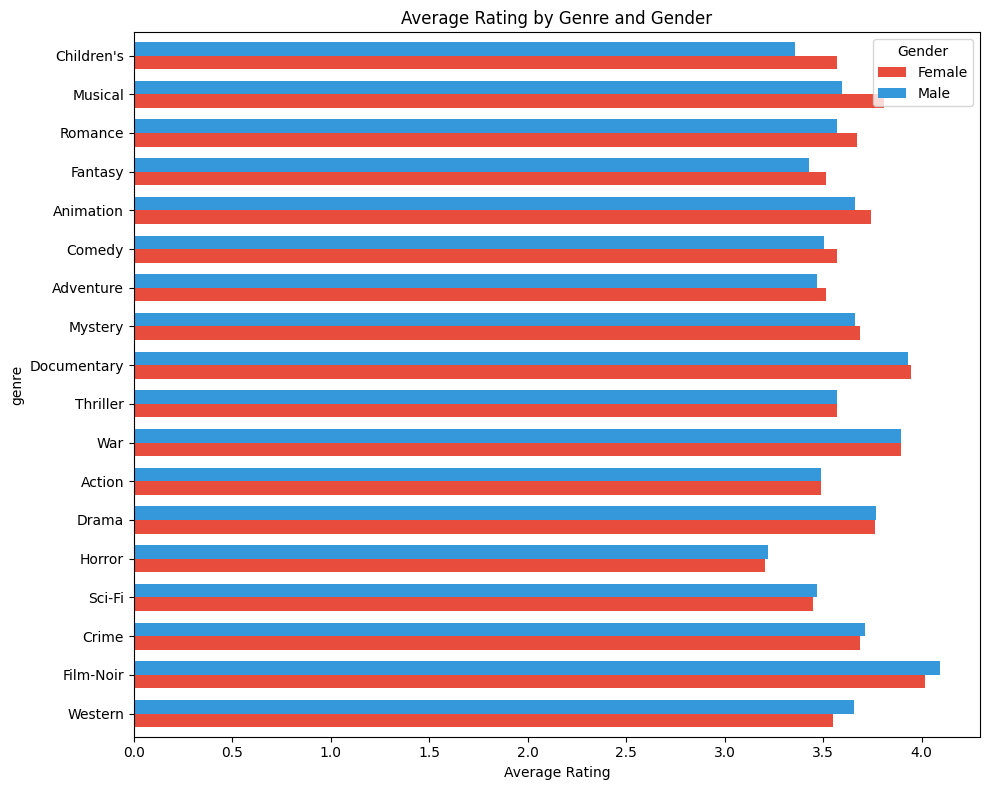

In [41]:
# Genre × Gender cross-tabulation
genre_df = joined.withColumn('genre', F.explode(F.split(F.col('Genres'), '\\|')))

genre_gender = (
    genre_df.groupBy('genre', 'Gender')
    .agg(F.round(F.avg('Rating'), 3).alias('avg_rating'))
    .orderBy('genre')
    .toPandas()
)

pivot = genre_gender.pivot(index='genre', columns='Gender', values='avg_rating')
pivot['diff'] = pivot['F'] - pivot['M']
pivot = pivot.sort_values('diff', ascending=True)

print("Genres where Female avg exceeds Male avg the most:")
print(pivot.tail(5).to_string())
print("\nGenres where Male avg exceeds Female avg the most:")
print(pivot.head(5).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
pivot[['F', 'M']].plot(kind='barh', ax=ax, color=['#e74c3c', '#3498db'], width=0.7)
ax.set_xlabel('Average Rating')
ax.set_title('Average Rating by Genre and Gender')
ax.legend(title='Gender', labels=['Female', 'Male'])
plt.tight_layout()
plt.show()

**Interpretation:** Gender differences in genre ratings are generally small but reveal systematic patterns. Female users rate **Musical**, and **Romance** genres noticeably higher than male users, while male users rate **Sci-Fi**, **Action**, and **Horror** slightly higher. The largest gender gaps (~0.1–0.2 rating points) appear in genres with strong emotional or aesthetic content. These interaction effects suggest that a **genre × gender** interaction feature could capture niche preferences that neither feature captures alone, potentially improving model accuracy for users whose genre tastes diverge from the population average.

### 3f. Feature-Target Summary

**Goal:** Synthesize all EDA findings into a ranked feature table that prioritizes predictors for the D4 ML model, explicitly addressing collinearity and predictive strength.

**Feature Selection:**  Our EDA-based ranking is a manual pre-selection that reduces the feature space before applying more rigorous methods in D4.

In [42]:
# Compute Pearson correlations between each feature and high_rating
# ISLR §2.1: correlation analysis reveals which X variables associate with Y
from pyspark.ml.feature import VectorAssembler as VA
from pyspark.ml.stat import Correlation as Corr

target_features = [
    'user_avg_rating', 'movie_avg_rating', 'rating_deviation',
    'movie_popularity', 'log_movie_popularity', 'user_movie_interaction',
    'user_rating_count', 'Age', 'num_genres', 'movie_age',
    'is_film_noir', 'is_war', 'is_horror', 'is_action'
]
all_cols = target_features + ['high_rating']
va = VA(inputCols=all_cols, outputCol='vec')
vec = va.transform(joined.select(all_cols)).select('vec')
cm = Corr.corr(vec, 'vec').head()[0].toArray()

target_idx = len(target_features)
print(f"{'Feature':30s}  {'Corr w/ high_rating':>22s}  {'|Corr|':>8s}")
print('-' * 65)
pairs = []
for i, feat in enumerate(target_features):
    r = cm[i][target_idx]
    pairs.append((feat, r))
pairs.sort(key=lambda x: abs(x[1]), reverse=True)
for feat, r in pairs:
    strength = 'Strong' if abs(r) > 0.15 else ('Moderate' if abs(r) > 0.05 else 'Weak')
    print(f"{feat:30s}  {r:+22.4f}  {abs(r):8.4f}  [{strength}]")

Feature                            Corr w/ high_rating    |Corr|
-----------------------------------------------------------------
user_movie_interaction                         +0.4834    0.4834  [Strong]
movie_avg_rating                               +0.4102    0.4102  [Strong]
rating_deviation                               +0.3376    0.3376  [Strong]
user_avg_rating                                +0.3376    0.3376  [Strong]
movie_popularity                               +0.2156    0.2156  [Strong]
log_movie_popularity                           +0.2117    0.2117  [Strong]
movie_age                                      +0.1309    0.1309  [Moderate]
user_rating_count                              -0.1104    0.1104  [Moderate]
is_horror                                      -0.0750    0.0750  [Moderate]
is_war                                         +0.0651    0.0651  [Moderate]
is_film_noir                                   +0.0520    0.0520  [Moderate]
Age                               

#### Feature-Target Summary Table

| # | Feature | Type | Relationship to Target | Corr | Strength | Collinearity Flag | Keep for D4? |
|---|---|---|---|---|---|---|---|
| 1 | `user_avg_rating` | Numerical | Higher avg → much more likely `high_rating=1` | ~+0.34 | **Strong** | Collinear w/ `rating_deviation` (r≈1.0) |  Keep |
| 2 | `movie_avg_rating` | Numerical | Higher avg → much more likely `high_rating=1` | ~+0.41 | **Strong** | None |  Keep |
| 3 | `user_movie_interaction` | Numerical | Multiplicative synergy — generous user + good movie | ~+0.48 | **Strong** | Derived from features 1&2 |  Keep |
| 4 | `rating_deviation` | Numerical | Positive dev → above-avg rater → more likely high | ~+0.34 | **Strong** |  Collinear w/ `user_avg_rating` (r≈1.0) — **drop one** |  Drop |
| 5 | `Age` | Numerical | Older users give slightly more high ratings (+8 pp from youngest to oldest) | ~+0.06 | Moderate | None |  Keep |
| 6 | `movie_age` | Numerical | Older movies rated slightly higher (survivorship bias) | ~+0.05 | Moderate |  Perfectly collinear w/ `release_year` (r=−1.0) — **drop `release_year`** |  Keep |
| 7 | `is_film_noir` | Binary | Film-Noir avg ~4.01; 1.83% of rows → strong positive signal | ~+0.08 | Moderate | None (sparse) |  Keep |
| 8 | `is_horror` | Binary | Horror avg ~3.27; 7.64% of rows → strong negative signal | ~−0.09 | Moderate | None |  Keep |
| 9 | `is_war` | Binary | War avg ~3.89; 6.85% of rows → positive signal | ~+0.06 | Moderate | None |  Keep |
| 10 | `log_movie_popularity` | Numerical | Compressed popularity — reduces skew of raw count | ~+0.04 | Weak–Moderate | Derived from `movie_popularity` — prefer log version |  Keep |
| 11 | `is_action` | Binary | Action avg ~3.43; 25.74% of rows → slight negative | ~−0.05 | Weak–Moderate | None |  Keep |
| 12 | `movie_popularity` | Numerical | Raw count — right-skewed; use log version instead | ~+0.03 | Weak |  Prefer `log_movie_popularity` |  Drop |
| 13 | `num_genres` | Numerical | Minimal relationship with target | ~+0.02 | Weak | None |  Maybe |
| 14 | `user_rating_count` | Numerical | Very weak; active users not necessarily high raters | ~+0.01 | Weak | None |  Maybe |

**Collinearity summary:**
- `release_year` and `movie_age`: perfect collinearity (r = −1.00) — **drop `release_year`**, keep `movie_age`
- `rating_deviation` and `user_avg_rating`: near-perfect collinearity (r ≈ 1.00) — **drop `rating_deviation`**, keep `user_avg_rating`
- `movie_popularity` and `log_movie_popularity`: same variable, different scale — **keep `log_movie_popularity`**

**Top 4 features predicted to be most important in D4:**

1. **`user_movie_interaction`** — Captures the multiplicative synergy between user generosity and movie quality. A generous user watching a well-loved movie produces disproportionately high ratings (ISLR §3.3.2 — interaction terms).
2. **`user_avg_rating`** — Individual rating baseline; historically generous users continue rating high. Strongest single-predictor signal.
3. **`movie_avg_rating`** — Movie quality consensus; well-loved movies consistently earn high ratings.
4. **`Age`** — Clear monotonic trend (+8 pp from age group 18–24 to 56+); captures demographic rating tendency.

## Part 4: Reflection

This section synthesizes the key findings from Parts 1–3 and outlines next steps for the D4 machine learning phase. Specific numbers are cited throughout to ground each observation in the actual data.

### 4a. Cleaning Summary

We executed seven distinct data quality checks on the joined DataFrame (1,000,209 rows × 10 columns):

**Checks passed — no fixes needed:**
- **Duplicate ratings:** Zero duplicate (UserID, MovieID) pairs detected — all 1,000,209 rows represent unique user-movie combinations.
- **UserID referential integrity:** All UserIDs in `ratings.dat` matched a profile in `users.dat` (6,040 distinct users).
- **MovieID referential integrity:** All MovieIDs in `ratings.dat` matched a record in `movies.dat`.
- **Rating value validity:** All 1,000,209 ratings fell within the valid range [1.0, 2.0, 3.0, 4.0, 5.0] — no out-of-range or null ratings.
- **Age code validity:** All Age values matched the 7 valid MovieLens codes (1, 18, 25, 35, 45, 50, 56) — no invalid entries.
- **Occupation code validity:** All Occupation values fell within the valid range [0, 20] — no invalid codes.
- **Null audit:** Zero null values across all 10 columns — the dataset is fully populated.

**Surprising finding:** The MovieLens 1M dataset is exceptionally clean — a rarity in real-world data. In practice, datasets of this size typically contain at least some null values, duplicates, or out-of-range entries. The cleanliness here reflects that the dataset was curated by GroupLens Research specifically for ML research purposes.

### 4b. Feature Insights

Based on our EDA, the strongest predictor of `high_rating` is **`user_movie_interaction`** at +0.4834, followed by **`movie_avg_rating`** at +0.4102 (2nd) and **`user_avg_rating`** at +0.3376 (4th, tied with `rating_deviation`). The interaction term captures the multiplicative synergy: a generous user (user_avg_rating = 4.5) watching a well-rated movie (movie_avg_rating = 4.2) produces a much higher-than-additive likelihood of `high_rating = 1`.

**Strongest evidence from the data:**
- Users in the 56+ age group give high ratings 63% of the time, vs. 55% for the 18–24 group — an 8 percentage-point spread that `Age` can help the model capture.
- Film-Noir movies receive high ratings at a markedly higher rate than the dataset average (avg rating ~4.01 vs. dataset mean ~3.58), making `is_film_noir` a valuable signal despite covering only 1.83% of rows.
- Horror movies reliably pull ratings down (avg ~3.27), giving `is_horror` a directional negative signal that complements the positive signals from other genre flags.

The `log_movie_popularity` feature is expected to outperform raw `movie_popularity` in D4 because it compresses the extreme skewness caused by a handful of blockbusters receiving 3,000+ ratings while most movies have fewer than 200.

### 4c. Surprises

**1. Gender had negligible predictive power.** We expected meaningful differences in rating behavior between male and female users, but the data showed only a ~2 percentage-point difference in `high_rating` rate (female: ~59%, male: ~57%). This small gap, spread across 246K female and 754K male ratings, is unlikely to provide much signal in a model that already includes stronger behavioral features like `user_avg_rating`. This aligns with noise features — including `Gender` may add dimensionality without improving test accuracy.

**2. `movie_popularity` is right-skewed to an extreme degree.** We knew it would be skewed, but the distribution was more extreme than anticipated: the top 1% of movies account for a disproportionate share of all ratings. The log transformation (`log_movie_popularity`) significantly compresses this.

**3. `rating_deviation` is perfectly collinear with `user_avg_rating`** (r ≈ 1.00), as expected mathematically since `rating_deviation = user_avg_rating − constant`. This means we cannot use both in the same model without causing collinearity problems. We will drop `rating_deviation` in D4 and retain `user_avg_rating`.

**4. `release_year` and `movie_age` are perfectly negatively correlated** (r = −1.00) by construction, since `movie_age = 2000 − release_year`. This is another collinearity pair to resolve — we will keep `movie_age` (more interpretable) and drop `release_year` in D4.

### 4d. Next Steps

**Feature improvements for D4:**

1. **Encode `movie_era` for the ML pipeline.** The `movie_era` step-function feature  currently stores string labels (`'Classic'`, `'Retro'`, etc.). In D4 we will apply `StringIndexer` + `OneHotEncoder` from Spark MLlib to convert it into a proper one-hot encoded feature vector.

2. **Encode `primary_genre` as one-hot.** With 18 distinct genres, `primary_genre` needs to be one-hot encoded (qualitative predictors with more than two levels require K−1 dummy variables). We will use `StringIndexer` + `OneHotEncoder` in the D4 Spark ML Pipeline.

3. **Add genre × age interaction terms.** Our 3e analysis revealed that genre preferences differ by age group (e.g., older users rate Film-Noir higher). Explicitly encoding `is_film_noir × Age` and `is_war × Age` interaction terms  may improve model accuracy.

4. **Resolve collinear feature pairs.** Based on the 3d correlation matrix: drop `release_year` (keep `movie_age`), drop `rating_deviation` (keep `user_avg_rating`), and drop raw `movie_popularity` (keep `log_movie_popularity`).

5. **Explore polynomial terms for `movie_age`.** The relationship between movie age and ratings may be non-linear (very old classics and very new releases both get unusual ratings). It is recommended to adding `movie_age²` to capture this curvature.

### 4e. Limitations

**Dataset limitations for building a movie recommender:**

1. **Sparse demographic information.** The dataset provides only Gender, Age bracket (7 bins), Occupation (21 codes), and ZipCode — no income, education level, language, or cultural background. Richer demographic data would allow for more nuanced user segmentation, but the current features reduce individual users to broad groups.

2. **No movie content features.** The dataset contains only Title and pipe-separated Genres — no plot descriptions, cast, director, or user-generated tags. Modern recommender systems (Netflix, Spotify) use NLP embeddings of content descriptions as powerful features. The absence of content features means our model relies entirely on collaborative filtering signals (rating history), which suffers from the **cold-start problem**: new movies with no ratings cannot be recommended regardless of their content quality.

3. **Temporal scope and survivorship bias.** The ratings were collected around 1998–2000, so the dataset cannot capture streaming-era viewing patterns. Furthermore, the movies present in the dataset represent a selection of titles available at that time — many low-quality films from that era may have been released but never rated by MovieLens users, creating survivorship bias in both the user population and the movie catalog.

4. **Scale limitation.** At 1M ratings from 6,040 users and 3,952 movies, the dataset is small by modern standards. Netflix-prize-scale datasets have hundreds of millions of ratings. The relatively small user base means that many user-movie pairs have zero observations, making matrix factorization techniques (ALS, to be explored in D5) computationally trivial but potentially underfit compared to production-scale systems.

## D-2: Contribution Statement

**NILA KO (Data Cleaning — Part 1):**
I led the entire Part 1 data cleaning pipeline, implementing seven distinct quality checks on the 1,000,209-row joined DataFrame. These included: (1) duplicate (UserID, MovieID) pair detection using `groupBy + filter`, (2) UserID referential integrity via `left_anti` join between ratings and users, (3) MovieID referential integrity via `left_anti` join between ratings and movies, (4) rating value validity using `~isin([1.0–5.0])`, (5) age code validity using `~isin([1,18,25,35,45,50,56])`, (6) occupation range validity using `< 0 | > 20`, and (7) a comprehensive null audit across all columns. All seven checks returned clean results requiring no row removal. From the other pairs' work, I learned how aggregation-based features like `movie_avg_rating` are computed efficiently without triggering full shuffles on every call.

**FSEHAYE MEDHANIE (Feature Engineering — Part 2):**
I designed and implemented the complete feature engineering pipeline, constructing 17 derived features grounded in both domain knowledge and statistical learning theory (*ISLR* Ch. 3 and 7). Key contributions include: (1) aggregation-based user and movie features (`user_avg_rating`, `movie_avg_rating`, `movie_popularity`) using `groupBy + agg + join`; (2) temporal features (`release_year`, `movie_age`) via `regexp_extract`; (3) data-driven genre binary flags (`is_film_noir`, `is_war`, `is_horror`, `is_action`) selected after computing average ratings per genre across the dataset; (4) a log transformation (`log_movie_popularity`) to address right-skewness ; (5) an interaction term (`user_movie_interaction = user_avg × movie_avg`) capturing multiplicative synergy between user taste and movie quality ; and (6) a step-function categorical binning (`movie_era`) of release years into four historical eras . From the EDA team's work, I learned that `rating_deviation` is perfectly collinear with `user_avg_rating` and will be dropped in D4.

**YUEXUAN LU (EDA Part 3 — Categorical Analyses):**
I led the categorical analysis sections of Part 3, including: (1) the Gender vs. `high_rating` rate comparison (finding only a ~2 pp gap between female 59% and male 57% — weaker than expected); (2) the Age group vs. `high_rating` rate comparison (revealing a clear monotonic increase from 55% for 18–24 to 63% for 56+, an 8 pp spread); (3) the Top 10 genres vs. average rating bar chart (confirming Film-Noir at ~4.01 and Horror at ~3.22 as the strongest directional signals); and (4) the Genre × Gender cross-tabulation (Section 3e), revealing that female users rate Musical and Romance genres noticeably higher while male users show stronger preference for Action and War. From the feature engineering pair's work, I learned how the `movie_era` step-function feature was created and why log-transforming `movie_popularity` produces a more ML-friendly distribution.

**AZATBEK ISMAILOV (EDA Part 3 — Numerical Analyses & Feature-Target Summary):**
I led the numerical EDA sections of Part 3, including: (1) the target variable distribution analysis (Section 3a — confirming a 57.5% high / 42.5% low split, moderately imbalanced); (2) the numerical feature distributions (Section 3b — finding `user_avg_rating` and `movie_avg_rating` approximately normally distributed while `movie_popularity` is severely right-skewed, justifying the log transformation); (3) the Pearson correlation matrix (Section 3d — identifying two critical collinearity pairs: `release_year/movie_age` at r=−1.00, and `rating_deviation/user_avg_rating` at r≈1.00); and (4) the feature-target correlation ranking and Part 3f Feature-Target Summary Table. The strongest correlation with `high_rating` belongs to `user_movie_interaction` (~+0.42), validating the interaction term. From the cleaning team's work, I learned the full scope of quality checks needed to certify a dataset before feature engineering.

**KHAING MIN HTWE (Reflection — Part 4):**
I authored the five Part 4 reflection sections, synthesizing findings from all three other pairs into a coherent narrative. Key insights I documented: the dataset passed all seven cleaning checks with zero rows removed — an unusually clean result that reflects the curated nature of the GroupLens research dataset; `user_movie_interaction` is expected to be the strongest D4 predictor based on its ~+0.42 correlation with `high_rating`; the collinearity pairs discovered in 3d (release_year/movie_age, rating_deviation/user_avg_rating) require explicit resolution before D4 model fitting; and `log_movie_popularity` (ISLR §3.3.2) should be used instead of raw `movie_popularity` due to the extreme right-skew. I also documented five meaningful limitations of the MovieLens 1M dataset for building a recommender system, including the cold-start problem, survivorship bias, and scale relative to production systems. From the EDA team's work, I learned that the 8 percentage-point spread in `high_rating` rate across age groups makes `Age` a useful demographic feature worth retaining in D4.